In [1]:
!pip install -q transformers==4.44.2 datasets accelerate evaluate scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 135.6 MB/s eta 0:00:00


In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, auc
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:


BASE_PATH = "/content/drive/MyDrive/Research Code and Data/"
PROCESSED_PATH = BASE_PATH + "data_processed/"
SPLIT_PATH = PROCESSED_PATH + "splits/"
RESULTS_PATH = BASE_PATH + "results/muril/"

os.makedirs(RESULTS_PATH, exist_ok=True)

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [6]:
MODEL_NAME = "google/muril-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
MAX_LEN = 128
EPOCHS = 3
LR = 2e-5
BATCH_SIZE = 16

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    acc = accuracy_score(labels, preds)

    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    roc_auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [9]:

def train_on_dataset(dataset_name):

    print(f"\n======== Training MuRIL on {dataset_name.upper()} ========\n")

    # Load CSV
    train_df = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_train.csv")
    val_df   = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_val.csv")
    test_df  = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_test.csv")

    # Clean
    def clean_dataframe(df):
        df = df.dropna(subset=["text", "label"])
        df["text"] = df["text"].astype(str)
        df = df[df["text"].str.strip() != ""]
        df = df.reset_index(drop=True)
        return df

    train_df = clean_dataframe(train_df)
    val_df   = clean_dataframe(val_df)
    test_df  = clean_dataframe(test_df)

    train_ds = Dataset.from_pandas(train_df)
    val_ds   = Dataset.from_pandas(val_df)
    test_ds  = Dataset.from_pandas(test_df)

    # Tokenize
    train_ds = train_ds.map(tokenize_function, batched=True)
    val_ds   = val_ds.map(tokenize_function, batched=True)
    test_ds  = test_ds.map(tokenize_function, batched=True)

    train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=RESULTS_PATH + dataset_name,
        evaluation_strategy="epoch",
        save_strategy="no",              # Disk safe
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    trainer.train()
    runtime = time.time() - start_time

    print("\nEvaluating on TEST set...\n")
    test_metrics = trainer.evaluate(test_ds)

    # ROC
    predictions = trainer.predict(test_ds)
    logits = predictions.predictions
    labels = predictions.label_ids

    probabilities = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - MuRIL - {dataset_name}")
    plt.legend()
    plt.show()

    test_metrics["eval_roc_auc"] = roc_auc
    test_metrics["runtime_seconds"] = runtime
    test_metrics["dataset"] = dataset_name

    # Cleanup
    del trainer
    del model
    torch.cuda.empty_cache()

    return test_metrics


======== Training MuRIL on THAR ========



Map:   0%|          | 0/8082 [00:00<?, ? examples/s]

Map:   0%|          | 0/1732 [00:00<?, ? examples/s]

Map:   0%|          | 0/1732 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.619500,0.603963,0.701501,0.641315,0.834963,0.725438,0.766805
2,0.535500,0.553878,0.731524,0.723135,0.699267,0.711001,0.812189
3,0.498800,0.548166,0.745381,0.715922,0.764059,0.739208,0.817405



Evaluating on TEST set...



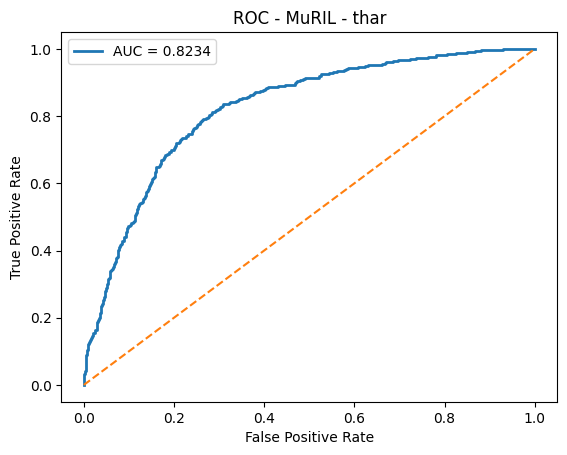


======== Training MuRIL on HASOC ========



Map:   0%|          | 0/4684 [00:00<?, ? examples/s]

Map:   0%|          | 0/1004 [00:00<?, ? examples/s]

Map:   0%|          | 0/1004 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.636700,0.550587,0.756972,0.742747,0.775758,0.758893,0.791820
2,0.522200,0.526805,0.771912,0.775934,0.755556,0.765609,0.819984
3,0.518900,0.519718,0.776892,0.756144,0.808081,0.781250,0.835463



Evaluating on TEST set...



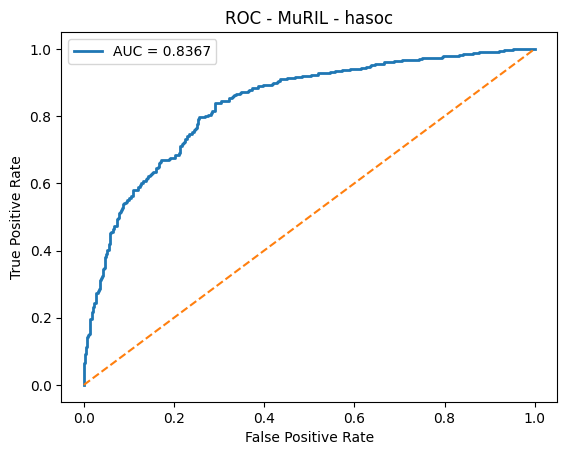


======== Training MuRIL on AOLD ========



/tmp/ipython-input-4500/2407904246.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["text"].astype(str)


Map:   0%|          | 0/5641 [00:00<?, ? examples/s]

Map:   0%|          | 0/1209 [00:00<?, ? examples/s]

Map:   0%|          | 0/1210 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.596400,0.560180,0.742763,0.621053,0.330532,0.431444,0.676469
2,0.519200,0.517334,0.763441,0.668246,0.394958,0.496479,0.787582
3,0.448100,0.516018,0.777502,0.692982,0.442577,0.540171,0.763705



Evaluating on TEST set...



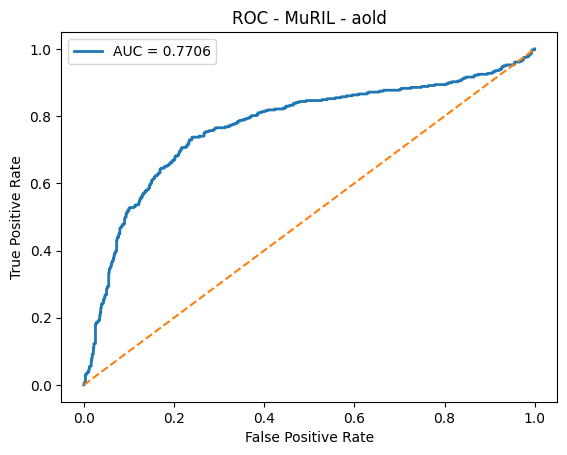


======== Training MuRIL on COMBINED ========



/tmp/ipython-input-4500/2407904246.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text"] = df["text"].astype(str)


Map:   0%|          | 0/18408 [00:00<?, ? examples/s]

Map:   0%|          | 0/3945 [00:00<?, ? examples/s]

Map:   0%|          | 0/3945 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.545600,0.551412,0.729785,0.657634,0.755236,0.703064,0.794641
2,0.481400,0.520795,0.753359,0.693245,0.749252,0.720161,0.828474
3,0.457600,0.521020,0.758935,0.710280,0.727708,0.718889,0.834765



Evaluating on TEST set...



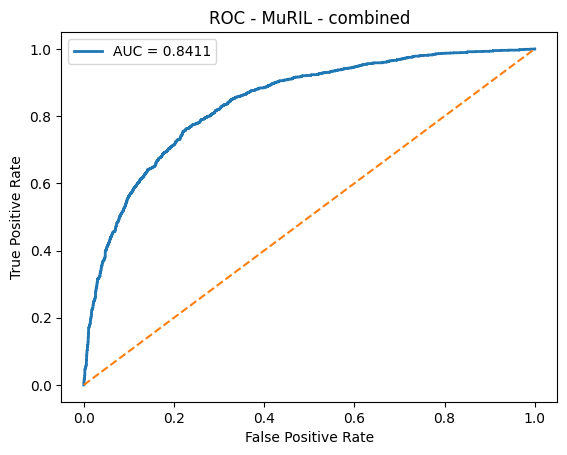

In [10]:
datasets = ["thar", "hasoc", "aold", "combined"]

summary = []

for ds in datasets:
    result = train_on_dataset(ds)
    summary.append(result)



In [11]:
results_df = pd.DataFrame(summary)
results_df.to_csv(RESULTS_PATH + "muril_results.csv", index=False)

results_df

,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,runtime_seconds,dataset
0,0.526618,0.760970,0.727991,0.788509,0.757042,0.823431,3.0189,573.713,36.105,3.0,161.699500,thar
1,0.538036,0.762948,0.738404,0.804040,0.769826,0.836709,1.7519,573.097,35.961,3.0,90.535429,hasoc
2,0.496638,0.785950,0.695652,0.491620,0.576105,0.770592,2.1081,573.977,36.051,3.0,108.610633,aold
3,0.509350,0.766286,0.716185,0.741916,0.728824,0.841094,6.8519,575.750,36.048,3.0,354.665984,combined


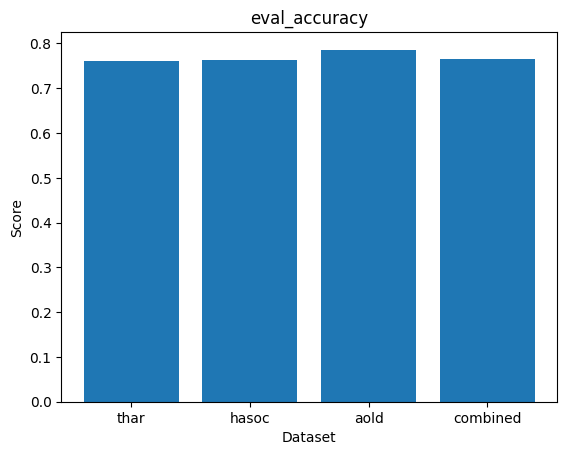

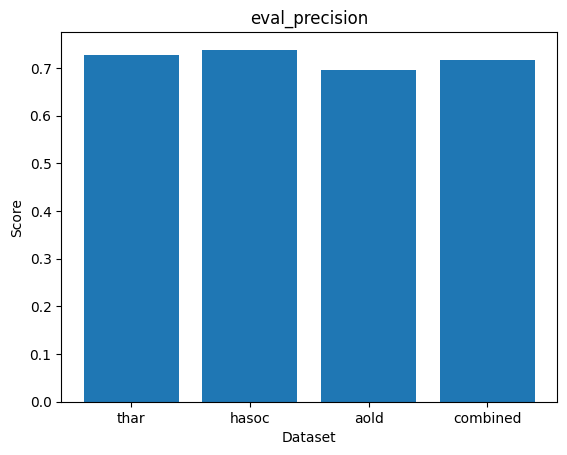

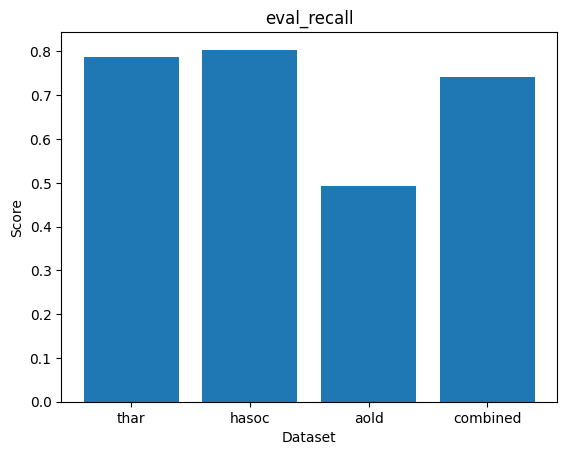

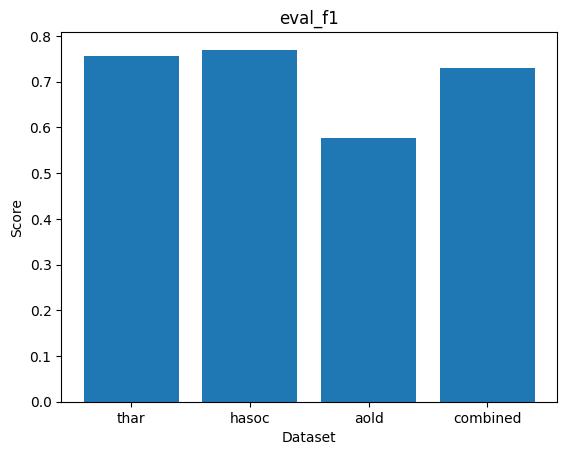

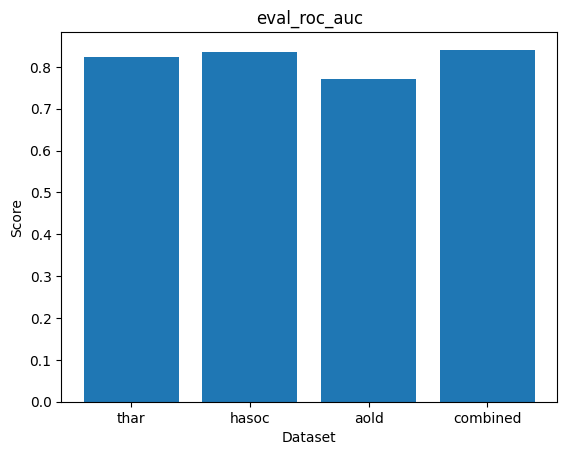

In [12]:
metrics_to_plot = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1", "eval_roc_auc"]

for metric in metrics_to_plot:
    plt.figure()
    plt.bar(results_df["dataset"], results_df[metric])
    plt.title(metric)
    plt.ylabel("Score")
    plt.xlabel("Dataset")
    plt.show()